# Setup Notes

This notebook demonstrates the **Fight Fire with Fire** defense method against adversarial patch attacks on object detectors.

## What is Trained vs. What is Not

| Component | Trained? | Notes |
|---|---|---|
| **Canary patch** | ✅ Yes | Optimized via gradient-based patch optimization |
| **Woodpecker patch** | ✅ Yes | Optimized via gradient-based patch optimization |
| **YOLO (YOLOv2/v4/YOLOR/YOLOv8)** | ❌ No | Used pre-trained and frozen |
| **Faster R-CNN** | ❌ No | Used pre-trained and frozen |

## Key Point

> **Only the canary and woodpecker defensive patches are trained — the YOLO detector is never retrained or modified.**

The YOLO model acts as a **fixed, frozen oracle**. During patch optimization, we backpropagate through YOLO's computational graph to update only the **pixel values** of the defensive patch — never the model weights. This is a core contribution of the paper: the defense works without any modification to the target detector.

# Dataset Overview

The training data lives in `Data/traineval/VOC07_YOLOv8/train_120/` and contains **360 files** split into three folders:

| Folder | Contents | Count |
|---|---|---|
| `benign/` | Clean original images (JPEG) | 120 |
| `adversarial/` | Same images with adversarial patches applied (JPEG) | 120 |
| `benign_label/` | YOLO-format annotation files (.txt) for the benign images | 120 |

**Label format:** Each `.txt` file follows YOLO convention — one object per line:
```
class_id  x_center  y_center  width  height
```
All coordinates are normalized to [0, 1].

**Pre-trained defensive patches** (ready to use, no retraining needed) are in `trained_dfpatches/`, one `canary.png` and `wd.png` per detector:
```
trained_dfpatches/
├── FSRCNN/   canary.png  wd.png
├── YOLOv2/   canary.png  wd.png
├── YOLOv4/   canary.png  wd.png
├── YOLOR/    canary.png  wd.png
└── YOLOv8/   canary.png  wd.png
```

The cell below verifies all expected files are present.

In [1]:
import os
from pathlib import Path

BASE = Path(".")
DATA = BASE / "Data/traineval/VOC07_YOLOv8/train_120"
PATCHES = BASE / "trained_dfpatches"
DETECTORS = ["FSRCNN", "YOLOv2", "YOLOv4", "YOLOR", "YOLOv8"]

print("=" * 55)
print("DATASET CHECK")
print("=" * 55)

# --- Training data ---
folders = {
    "benign":       ("*.jpg", 120),
    "adversarial":  ("*.jpg", 120),
    "benign_label": ("*.txt", 120),
}

all_ok = True
for folder, (pattern, expected) in folders.items():
    path = DATA / folder
    if not path.exists():
        print(f"  [MISSING]  {folder}/")
        all_ok = False
        continue
    found = len(list(path.glob(pattern)))
    status = "OK" if found == expected else "WARN"
    print(f"  [{status}]  {folder}/  →  {found}/{expected} files")
    if found != expected:
        all_ok = False

print()
print("=" * 55)
print("PRE-TRAINED DEFENSIVE PATCHES CHECK")
print("=" * 55)

for det in DETECTORS:
    for patch in ["canary.png", "wd.png"]:
        p = PATCHES / det / patch
        status = "OK" if p.exists() else "MISSING"
        size = f"{p.stat().st_size // 1024} KB" if p.exists() else "—"
        print(f"  [{status}]  trained_dfpatches/{det}/{patch}  ({size})")
    if not all_ok:
        all_ok = False

print()
print("=" * 55)
if all_ok:
    print("All files verified — dataset is ready.")
else:
    print("Some files are missing — check the paths above.")
print("=" * 55)


DATASET CHECK
  [OK]  benign/  →  120/120 files
  [OK]  adversarial/  →  120/120 files
  [OK]  benign_label/  →  120/120 files

PRE-TRAINED DEFENSIVE PATCHES CHECK
  [OK]  trained_dfpatches/FSRCNN/canary.png  (39 KB)
  [OK]  trained_dfpatches/FSRCNN/wd.png  (42 KB)
  [OK]  trained_dfpatches/YOLOv2/canary.png  (10 KB)
  [OK]  trained_dfpatches/YOLOv2/wd.png  (10 KB)
  [OK]  trained_dfpatches/YOLOv4/canary.png  (10 KB)
  [OK]  trained_dfpatches/YOLOv4/wd.png  (10 KB)
  [OK]  trained_dfpatches/YOLOR/canary.png  (42 KB)
  [OK]  trained_dfpatches/YOLOR/wd.png  (57 KB)
  [OK]  trained_dfpatches/YOLOv8/canary.png  (18 KB)
  [OK]  trained_dfpatches/YOLOv8/wd.png  (18 KB)

All files verified — dataset is ready.


# Train / Test Split & Training Configuration

## Data Split

The 120-sample set in `Data/traineval/VOC07_YOLOv8/train_120/` is used **only for training** the defensive patches (canary & woodpecker). It is **not** split into train/val/test — the full 120 pairs (benign + adversarial) are used to optimize the patch pixels.

Evaluation (testing) is done separately using the pre-trained patches against held-out attack scenarios, **not** from this folder.

## Pre-trained Patches (the "weights")

Because no model weights are saved (YOLO is frozen), the output of training is simply the patch image files:

```
trained_dfpatches/
└── YOLOv8/
    ├── canary.png   ← output of canary training
    └── wd.png       ← output of woodpecker training
```

If these files already exist, there is no need to retrain.

## FORCE_RETRAIN Flag

The cell below controls whether to retrain:

| `FORCE_RETRAIN` | Patches exist? | Action |
|---|---|---|
| `False` | ✅ Yes | Skip training — use existing patches |
| `False` | ❌ No  | Train automatically (patches missing) |
| `True`  | either | Always retrain and overwrite patches |

In [2]:
from pathlib import Path

# ─────────────────────────────────────────────
# FORCE_RETRAIN = True  → always retrain, even if outputs exist
# FORCE_RETRAIN = False → only retrain if outputs are missing in BOTH locations
# ─────────────────────────────────────────────
FORCE_RETRAIN = False

DETECTOR = "YOLOv8"  # change to FSRCNN / YOLOv2 / YOLOv4 / YOLOR as needed

# Location 1: FJNTraining — epoch snapshots produced during training
# (folder name matches default training args)
CANARY_TRAIN_DIR = Path("FJNTraining/canary_cc_fool_yolov8_2.0_10/exp_VOC07_120_22_80_50")
WD_TRAIN_DIR     = Path("FJNTraining/wd_cc_fool_yolov8_1.0_10/exp_VOC07_120_80_50")
CANARY_EPOCH_FINAL = CANARY_TRAIN_DIR / "canary_050.png"
WD_EPOCH_FINAL     = WD_TRAIN_DIR     / "wd_050.png"

# Location 2: trained_dfpatches/<DETECTOR> — manually placed pre-trained patches
PATCH_DIR   = Path("trained_dfpatches") / DETECTOR
CANARY_PRETRAINED = PATCH_DIR / "canary.png"
WD_PRETRAINED     = PATCH_DIR / "wd.png"

# Either location having the file means we don't need to retrain
canary_done = CANARY_EPOCH_FINAL.exists() or CANARY_PRETRAINED.exists()
wd_done     = WD_EPOCH_FINAL.exists()     or WD_PRETRAINED.exists()
training_done = canary_done and wd_done

SHOULD_TRAIN = FORCE_RETRAIN or not training_done

print("=" * 60)
print(f"  TRAINING OUTPUT CHECK  (detector: {DETECTOR})")
print("=" * 60)
print(f"  [FJNTraining]       canary_050.png : {'FOUND' if CANARY_EPOCH_FINAL.exists() else 'not found'}")
print(f"  [trained_dfpatches] canary.png     : {'FOUND' if CANARY_PRETRAINED.exists() else 'not found'}")
print(f"  [FJNTraining]       wd_050.png     : {'FOUND' if WD_EPOCH_FINAL.exists()     else 'not found'}")
print(f"  [trained_dfpatches] wd.png         : {'FOUND' if WD_PRETRAINED.exists()      else 'not found'}")
print(f"  FORCE_RETRAIN                      : {FORCE_RETRAIN}")
print("-" * 60)
if SHOULD_TRAIN:
    reason = "FORCE_RETRAIN=True" if FORCE_RETRAIN else "no canary/wd found in either location"
    print(f"  → Will TRAIN  ({reason})")
else:
    print(f"  → Will SKIP training (patches found)")
print("=" * 60)


  TRAINING OUTPUT CHECK  (detector: YOLOv8)
  [FJNTraining]       canary_050.png : FOUND
  [trained_dfpatches] canary.png     : FOUND
  [FJNTraining]       wd_050.png     : FOUND
  [trained_dfpatches] wd.png         : FOUND
  FORCE_RETRAIN                      : False
------------------------------------------------------------
  → Will SKIP training (patches found)


# Training the Defensive Patches

Training runs two separate commands — one for the **canary** and one for the **woodpecker** — using `YOLOv8_Combiner.py` with `--train` and `--df_mode`.

| Arg | Canary | Woodpecker |
|---|---|---|
| `--df_mode` | `C` | `W` |
| `--canary_cls_id` | `22` (zebra in VOC) | — |
| `--canary_size` / `--wd_size` | `80` | `80` |
| `--weight` | `2.0` | `1.0` |
| `--person_conf` | `0.05` | `0.05` |
| epochs | 50 | 50 |

Output is saved per-epoch to `FJNTraining/` as `canary_000.png` → `canary_050.png` and `wd_000.png` → `wd_050.png`.

The cell below runs both commands only if `SHOULD_TRAIN` is `True` (set in the previous cell).

In [3]:
import subprocess, sys

if not SHOULD_TRAIN:
    print("Skipping training — patches already exist. Set FORCE_RETRAIN=True to override.")
else:
    print("Starting canary training...")
    result = subprocess.run(
        [sys.executable, "YOLOv8_Combiner.py",
         "--train", "--df_mode", "C",
         "--defensive_patch_location", "cc",
         "--canary_cls_id", "22",
         "--canary_size", "80",
         "--person_conf", "0.05",
         "--weight", "2.0"],
        check=True
    )
    print("Canary training done.\n")

    print("Starting woodpecker training...")
    result = subprocess.run(
        [sys.executable, "YOLOv8_Combiner.py",
         "--train", "--df_mode", "W",
         "--defensive_patch_location", "cc",
         "--wd_size", "80",
         "--person_conf", "0.05",
         "--weight", "1.0"],
        check=True
    )
    print("Woodpecker training done.")


Skipping training — patches already exist. Set FORCE_RETRAIN=True to override.


# Testing — Canary Defense

Before running the canary defense, we first display the input image and run raw YOLOv8 on it to see what it detects normally (no defense applied yet).

c:\Users\moham\OneDrive\Desktop\Cybersecurity Project\FFF-COSC739-Extension\.\ultralytics\nn\tasks.py:563: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(fi

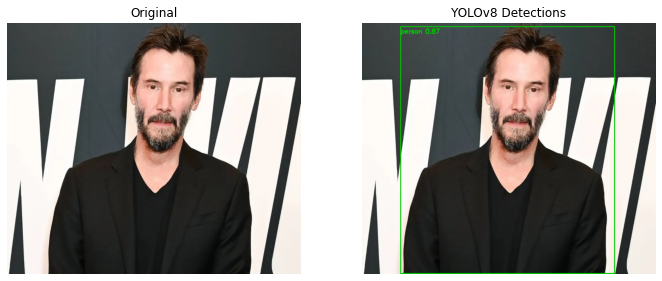

In [1]:
import sys
sys.path.insert(0, ".")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8

INPUT_IMG = "hady_test_samples/sample.jpg"

img_bgr = cv2.imread(INPUT_IMG)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Run YOLOv8
detector = FJN_YOLOv8()
detections = detector.detect_single(img_bgr)[0]  # [[x1,y1,x2,y2,conf,cls], ...]

# Draw boxes with labels that never go above the image
annotated = img_rgb.copy()
for *xyxy, conf, cls in detections:
    x1, y1, x2, y2 = map(int, xyxy)
    label = f"{detector.names[int(cls)]} {conf:.2f}"
    color = (0, 200, 0)  # green

    cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)

    # Put label inside the box if it would be cut off at the top
    font, scale, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
    (tw, th), _ = cv2.getTextSize(label, font, scale, thickness)
    ty = y1 - 6 if y1 - 6 > th else y1 + th + 6
    cv2.putText(annotated, label, (x1, ty), font, scale, color, thickness)

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb);    axes[0].set_title("Original");          axes[0].axis("off")
axes[1].imshow(annotated);  axes[1].set_title("YOLOv8 Detections"); axes[1].axis("off")
plt.tight_layout()
plt.show()


# Testing — Canary Defense on a Benign Image

We now apply the **canary** defense on the benign input image.

The canary is placed next to each detected person. If YOLO still detects the canary after placement → image is **clean**. If the canary disappears → image is **under attack**.

YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Load canary(22) for eval: trained_dfpatches/YOLOv8/canary.png
Canary verdict : CLEAN (no attack)
  canaries in image before placement : 0
  canaries placed                    : 0
  canaries detected after placement  : 0
  expected (0 + 0) = 0, got 0


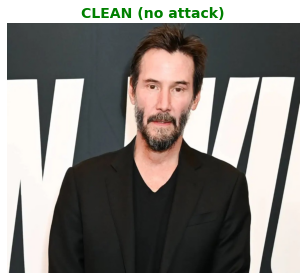

In [3]:
import sys, os
sys.path.insert(0, ".")

import importlib
import YOLOv8_Combiner
importlib.reload(YOLOv8_Combiner)
from YOLOv8_Combiner import Canary, freeze_seed

import cv2
import matplotlib.pyplot as plt
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8
import argparse

CANARY_PATH = "trained_dfpatches/YOLOv8/canary.png"
INPUT_IMG   = "hady_test_samples/sample.jpg"

cfg = argparse.Namespace(
    df_mode                  = "C",
    defensive_patch_location = "cc",
    canary_cls_id            = 22,
    canary_size              = 80,
    wd_size                  = 80,
    person_conf              = 0.05,
    overlap_thresh           = 0.4,
    img_size                 = 640,
    seed                     = 301,
    faster                   = False,
    eval_no_overlap          = True,
    margin_size              = 0,
    best_canary_path         = CANARY_PATH,
    best_wd_path             = "trained_dfpatches/YOLOv8/wd.png",
)

freeze_seed(cfg.seed)

detector = YOLOv8()
canary   = Canary(cfg, detector)
canary.eval_load_canary(canary_path=CANARY_PATH, canary_cls_id=cfg.canary_cls_id)

# Run canary defense on benign image
img_bgr = cv2.imread(INPUT_IMG, 1)
details = canary.eval_single(img_bgr, return_details=True)

verdict = "ATTACK DETECTED" if details["is_attack"] else "CLEAN (no attack)"
print(f"Canary verdict : {verdict}")
print(f"  canaries in image before placement : {details['canary_original_num']}")
print(f"  canaries placed                    : {details['canary_put_num']}")
print(f"  canaries detected after placement  : {details['canary_detected_num']}")
print(f"  expected ({details['canary_original_num']} + {details['canary_put_num']}) = {details['canary_original_num'] + details['canary_put_num']}, got {details['canary_detected_num']}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(img_rgb)
ax.set_title(verdict, fontsize=14, color=("red" if details["is_attack"] else "green"), fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show() 

# Adversarial Image — Raw YOLOv8 (No Defense)

We now run the **same raw YOLOv8** on the adversarial version of the image (`sample_adv.jpg`), which has an adversarial patch embedded. No canary defense is applied yet — this shows what the attacker achieves: the person goes undetected.

Detections on adversarial image: 8 object(s)


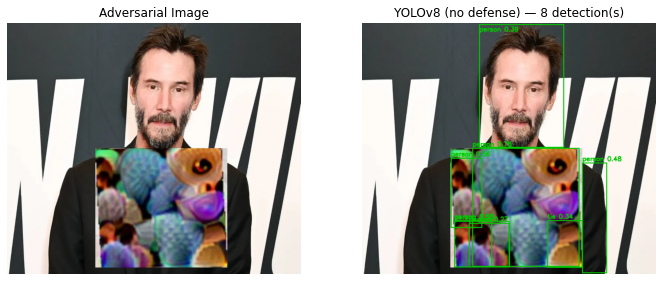

In [4]:
import cv2
import matplotlib.pyplot as plt

ADV_IMG = "hady_test_samples/sample_adv.jpg"

img_bgr = cv2.imread(ADV_IMG, 1)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Run YOLOv8 (detector already loaded above)
detections = detector.detect_single(img_bgr)[0]

annotated = img_rgb.copy()
for *xyxy, conf, cls in detections:
    x1, y1, x2, y2 = map(int, xyxy)
    label = f"{detector.names[int(cls)]} {conf:.2f}"
    color = (0, 200, 0)
    cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
    font, scale, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
    (tw, th), _ = cv2.getTextSize(label, font, scale, thickness)
    ty = y1 - 6 if y1 - 6 > th else y1 + th + 6
    cv2.putText(annotated, label, (x1, ty), font, scale, color, thickness)

n = len(detections)
print(f"Detections on adversarial image: {n} object(s)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb);    axes[0].set_title("Adversarial Image");          axes[0].axis("off")
axes[1].imshow(annotated);  axes[1].set_title(f"YOLOv8 (no defense) — {n} detection(s)"); axes[1].axis("off")
plt.tight_layout()
plt.show()


# Adversarial Image — Canary Defense Applied

Now we apply the **canary defense** on `sample_adv.jpg`. The canary patch is placed next to the detected person region. Because the adversarial patch is present, it will suppress the canary — YOLO will fail to detect it — and the defense flags the image as **under attack**.

Canary verdict : ATTACK DETECTED
  canaries in image before placement : 0
  canaries placed                    : 1
  canaries detected after placement  : 0
  expected (0 + 1) = 1, got 0


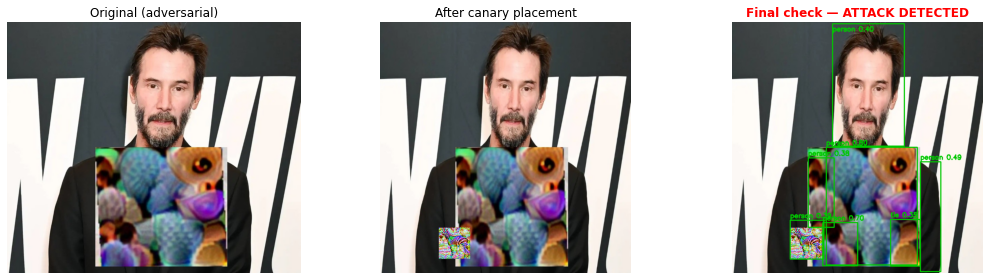

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ADV_IMG = "hady_test_samples/sample_adv.jpg"

img_bgr = cv2.imread(ADV_IMG, 1)
details = canary.eval_single(img_bgr, return_details=True)

verdict = "ATTACK DETECTED" if details["is_attack"] else "CLEAN (no attack)"
print(f"Canary verdict : {verdict}")
print(f"  canaries in image before placement : {details['canary_original_num']}")
print(f"  canaries placed                    : {details['canary_put_num']}")
print(f"  canaries detected after placement  : {details['canary_detected_num']}")
print(f"  expected ({details['canary_original_num']} + {details['canary_put_num']}) = {details['canary_original_num'] + details['canary_put_num']}, got {details['canary_detected_num']}")

# ── Panel 1: original image ──────────────────────────────────────────
orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ── Panel 2: image with canary placed ───────────────────────────────
canary_rgb = cv2.cvtColor(details["img_with_canary"], cv2.COLOR_BGR2RGB)

# ── Panel 3: detections on the canary image ──────────────────────────
final_rgb = canary_rgb.copy()
dets = details["detections_with_canary"]
if dets is not None and len(dets):
    for *xyxy, conf, cls in dets:
        x1, y1, x2, y2 = map(int, xyxy)
        label = f"{detector.names[int(cls)]} {conf:.2f}"
        color = (0, 200, 0) if int(cls) != canary.canary_cls_id else (255, 140, 0)
        cv2.rectangle(final_rgb, (x1, y1), (x2, y2), color, 2)
        font, scale, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2
        (_, th), _ = cv2.getTextSize(label, font, scale, thickness)
        ty = y1 - 6 if y1 - 6 > th else y1 + th + 6
        cv2.putText(final_rgb, label, (x1, ty), font, scale, color, thickness)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(orig_rgb);   axes[0].set_title("Original (adversarial)"); axes[0].axis("off")
axes[1].imshow(canary_rgb); axes[1].set_title("After canary placement"); axes[1].axis("off")
axes[2].imshow(final_rgb);  axes[2].set_title(f"Final check — {verdict}", color="red" if details["is_attack"] else "green", fontweight="bold"); axes[2].axis("off")
plt.tight_layout()
plt.show()


# Adversarial Image — Woodpecker Defense Applied

The **woodpecker** works differently from the canary. It places a counter-patch next to the detected person region. On an adversarial image, the woodpecker restores detection — a new person box appears that wasn't there before, which flags the image as **under attack**.

Load Woodpecker for eval: trained_dfpatches/YOLOv8/wd.png
Woodpecker verdict : CLEAN (no attack)
  persons detected before woodpecker : 7
  persons detected after woodpecker  : 5
  new person appeared                : False


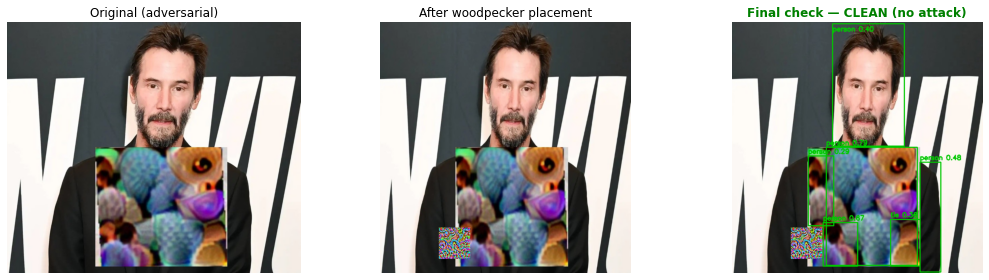

In [6]:
import importlib
import YOLOv8_Combiner
importlib.reload(YOLOv8_Combiner)
from YOLOv8_Combiner import Woodpecker

import cv2
import numpy as np
import matplotlib.pyplot as plt

WD_PATH = "trained_dfpatches/YOLOv8/wd.png"
ADV_IMG = "hady_test_samples/sample_adv.jpg"

woodpecker = Woodpecker(cfg, detector)
woodpecker.eval_load_wd(wd_path=WD_PATH)

img_bgr = cv2.imread(ADV_IMG, 1)
details = woodpecker.eval_single(img_bgr, return_details=True)

verdict = "ATTACK DETECTED" if details["is_attack"] else "CLEAN (no attack)"
print(f"Woodpecker verdict : {verdict}")
print(f"  persons detected before woodpecker : {details['persons_before']}")
print(f"  persons detected after woodpecker  : {details['persons_after']}")
print(f"  new person appeared                : {details['persons_after'] > details['persons_before']}")

# ── Panel 1: original adversarial image ─────────────────────────────
orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ── Panel 2: image with woodpecker placed ────────────────────────────
wd_rgb = cv2.cvtColor(details["img_with_wd"], cv2.COLOR_BGR2RGB)

# ── Panel 3: detections after woodpecker ────────────────────────────
final_rgb = wd_rgb.copy()
dets = details["detections_with_wd"]
if dets is not None and len(dets):
    for *xyxy, conf, cls in dets:
        x1, y1, x2, y2 = map(int, xyxy)
        label = f"{detector.names[int(cls)]} {conf:.2f}"
        color = (0, 200, 0)
        cv2.rectangle(final_rgb, (x1, y1), (x2, y2), color, 2)
        font, scale, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2
        (_, th), _ = cv2.getTextSize(label, font, scale, thickness)
        ty = y1 - 6 if y1 - 6 > th else y1 + th + 6
        cv2.putText(final_rgb, label, (x1, ty), font, scale, color, thickness)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(orig_rgb);  axes[0].set_title("Original (adversarial)");       axes[0].axis("off")
axes[1].imshow(wd_rgb);    axes[1].set_title("After woodpecker placement");    axes[1].axis("off")
axes[2].imshow(final_rgb); axes[2].set_title(f"Final check — {verdict}", color="red" if details["is_attack"] else "green", fontweight="bold"); axes[2].axis("off")
plt.tight_layout()
plt.show()


# Adversarial Image — Combined Defense (Canary + Woodpecker)

In mode `A` (All), both defenses are run in sequence:
1. **Canary** is checked first — if it flags an attack, we stop
2. If canary says clean, **Woodpecker** is checked as a second opinion

An attack is flagged if **either** triggers. This is the strongest defense mode.

Combined verdict : ATTACK DETECTED  (triggered by: canary)
  Canary    → ATTACK  (placed 1, detected 0)
  Woodpecker → clean  (persons before 7, after 5)


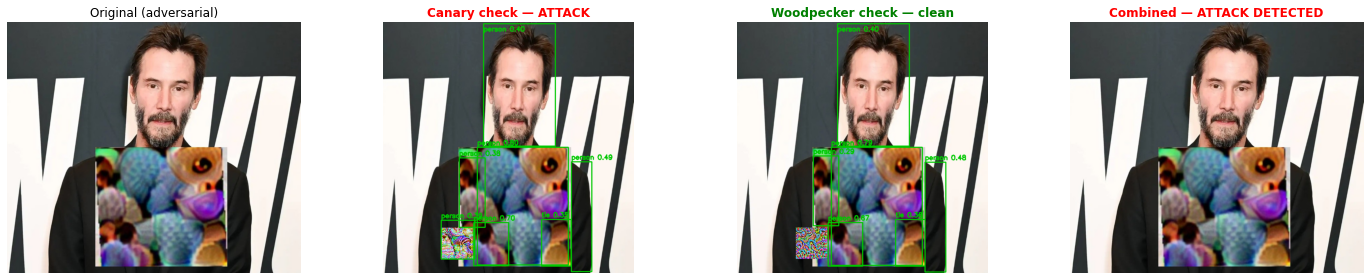

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ADV_IMG = "hady_test_samples/sample_adv.jpg"
img_bgr = cv2.imread(ADV_IMG, 1)

# Run canary first
canary_details = canary.eval_single(img_bgr, return_details=True)
is_attack = canary_details["is_attack"]
triggered_by = "canary" if is_attack else None

# If canary says clean, run woodpecker as second opinion
wd_details = woodpecker.eval_single(img_bgr, return_details=True)
if not is_attack:
    is_attack = wd_details["is_attack"]
    triggered_by = "woodpecker" if is_attack else None

verdict = "ATTACK DETECTED" if is_attack else "CLEAN (no attack)"
trigger_str = f"triggered by: {triggered_by}" if triggered_by else "neither triggered"
print(f"Combined verdict : {verdict}  ({trigger_str})")
print(f"  Canary    → {'ATTACK' if canary_details['is_attack'] else 'clean'}"
      f"  (placed {canary_details['canary_put_num']}, detected {canary_details['canary_detected_num']})")
print(f"  Woodpecker → {'ATTACK' if wd_details['is_attack'] else 'clean'}"
      f"  (persons before {wd_details['persons_before']}, after {wd_details['persons_after']})")

# ── Panels ───────────────────────────────────────────────────────────
orig_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
canary_rgb = cv2.cvtColor(canary_details["img_with_canary"], cv2.COLOR_BGR2RGB)
wd_rgb     = cv2.cvtColor(wd_details["img_with_wd"],     cv2.COLOR_BGR2RGB)

def draw_dets(img_rgb, dets, canary_cls_id=None):
    out = img_rgb.copy()
    if dets is not None and len(dets):
        for *xyxy, conf, cls in dets:
            x1, y1, x2, y2 = map(int, xyxy)
            label = f"{detector.names[int(cls)]} {conf:.2f}"
            color = (255, 140, 0) if (canary_cls_id and int(cls) == canary_cls_id) else (0, 200, 0)
            cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
            font, scale, thickness = cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2
            (_, th), _ = cv2.getTextSize(label, font, scale, thickness)
            ty = y1 - 6 if y1 - 6 > th else y1 + th + 6
            cv2.putText(out, label, (x1, ty), font, scale, color, thickness)
    return out

canary_final = draw_dets(canary_rgb, canary_details["detections_with_canary"], canary.canary_cls_id)
wd_final     = draw_dets(wd_rgb,     wd_details["detections_with_wd"])

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(orig_rgb);     axes[0].set_title("Original (adversarial)");       axes[0].axis("off")
axes[1].imshow(canary_final); axes[1].set_title(f"Canary check — {'ATTACK' if canary_details['is_attack'] else 'clean'}",
                                                  color="red" if canary_details["is_attack"] else "green", fontweight="bold"); axes[1].axis("off")
axes[2].imshow(wd_final);     axes[2].set_title(f"Woodpecker check — {'ATTACK' if wd_details['is_attack'] else 'clean'}",
                                                  color="red" if wd_details["is_attack"] else "green", fontweight="bold"); axes[2].axis("off")
axes[3].imshow(orig_rgb);     axes[3].set_title(f"Combined — {verdict}",
                                                  color="red" if is_attack else "green", fontweight="bold"); axes[3].axis("off")
plt.tight_layout()
plt.show()


# Batch Evaluation: Mode #1 (Canary), Mode #2 (Woodpecker), Mode #3 (Combined)

The single-image demos above show how each defense mode works on one example. Here we evaluate **all three FFF deployment modes** across the full VOC07 test set (4 attack scenarios, 749 adversarial + 749 benign images) and compare F1 scores and false positive rates.

| Mode | Strategy | Detection Signal |
|------|----------|-----------------|
| **#1 — Canary** | Place canary near candidate box | Canary disappears &#8594; attack |
| **#2 — Woodpecker** | Place woodpecker near candidate box | New person appears &#8594; attack |
| **#3 — Combined** | Canary first, then woodpecker if canary says clean | Either triggers &#8594; attack |

In [1]:
import sys, os, glob
sys.path.insert(0, ".")
import importlib, YOLOv8_Combiner
importlib.reload(YOLOv8_Combiner)
from YOLOv8_Combiner import Canary, Woodpecker, freeze_seed
from ObjectDetector.fjn_yolov8 import FJN_YOLOv8 as YOLOv8
import cv2, numpy as np, argparse

# ── Config (same as earlier cells) ──────────────────────────
cfg = argparse.Namespace(
    df_mode="C", defensive_patch_location="cc",
    canary_cls_id=22, canary_size=80, wd_size=80,
    person_conf=0.05, overlap_thresh=0.4, img_size=640,
    seed=301, faster=False, eval_no_overlap=True, margin_size=0,
    best_canary_path="trained_dfpatches/YOLOv8/canary.png",
    best_wd_path="trained_dfpatches/YOLOv8/wd.png",
)
freeze_seed(cfg.seed)

# ── Initialise detector + defenses ──────────────────────────
detector    = YOLOv8()
canary_def  = Canary(cfg, detector)
canary_def.eval_load_canary(canary_path=cfg.best_canary_path,
                            canary_cls_id=cfg.canary_cls_id)
wd_def      = Woodpecker(cfg, detector)
wd_def.eval_load_wd(wd_path=cfg.best_wd_path)

# ── Test data paths ─────────────────────────────────────────
TEST_ROOT = "Data/testeval/VOC07_YOLOv8/test"
ATTACKS = {
    "AdvPatch":  (f"{TEST_ROOT}/AdvPatch/adversarial",  f"{TEST_ROOT}/AdvPatch/benign"),
    "UPC":       (f"{TEST_ROOT}/UPC/adversarial",       f"{TEST_ROOT}/UPC/benign"),
    "TCEGA":     (f"{TEST_ROOT}/TCEGA/adversarial",     f"{TEST_ROOT}/TCEGA/benign"),
    "Natural":   (f"{TEST_ROOT}/Natural/adversarial",   f"{TEST_ROOT}/Natural/benign"),
}

def list_images(folder):
    imgs = sorted(glob.glob(os.path.join(folder, "*.jpg")))
    imgs += sorted(glob.glob(os.path.join(folder, "*.png")))
    return imgs

def compute_metrics(TP, FP, FN, TN):
    p   = TP / (TP + FP) if (TP + FP) > 0 else 0
    r   = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1  = 2 * p * r / (p + r) if (p + r) > 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    return p, r, f1, fpr

# ── Evaluate one mode across all attacks ────────────────────
def evaluate_mode(mode_name, mode_key):
    """mode_key: 'C' = canary, 'W' = woodpecker, 'A' = combined"""
    results = {}
    for atk, (adv_dir, ben_dir) in ATTACKS.items():
        TP = FP = FN = TN = 0
        adv_imgs = list_images(adv_dir)
        ben_imgs = list_images(ben_dir)
        total = len(adv_imgs) + len(ben_imgs)

        for i, path in enumerate(adv_imgs):
            img = cv2.imread(path, 1)
            if img is None:
                continue
            if mode_key == "C":
                is_attack = canary_def.eval_single(img)
            elif mode_key == "W":
                is_attack = wd_def.eval_single(img)
            else:  # 'A' combined
                is_attack = canary_def.eval_single(img)
                if not is_attack:
                    is_attack = wd_def.eval_single(img)
            if is_attack:
                TP += 1
            else:
                FN += 1
            if (i + 1) % 100 == 0:
                print(f"  {atk} adv: {i+1}/{len(adv_imgs)}", end="\r")

        for i, path in enumerate(ben_imgs):
            img = cv2.imread(path, 1)
            if img is None:
                continue
            if mode_key == "C":
                is_attack = canary_def.eval_single(img)
            elif mode_key == "W":
                is_attack = wd_def.eval_single(img)
            else:
                is_attack = canary_def.eval_single(img)
                if not is_attack:
                    is_attack = wd_def.eval_single(img)
            if is_attack:
                FP += 1
            else:
                TN += 1
            if (i + 1) % 100 == 0:
                print(f"  {atk} ben: {i+1}/{len(ben_imgs)}", end="\r")

        p, r, f1, fpr = compute_metrics(TP, FP, FN, TN)
        results[atk] = dict(TP=TP, FP=FP, FN=FN, TN=TN,
                            Prec=p, Rec=r, F1=f1, FPR=fpr)
        print(f"  {atk:10s}  F1={f1:.3f}  FPR={fpr:.3f}  "
              f"(TP={TP} FP={FP} FN={FN} TN={TN})")
    return results

# ── Run all three modes ─────────────────────────────────────
all_results = {}
for name, key in [("Mode #1 (Canary)", "C"),
                  ("Mode #2 (Woodpecker)", "W"),
                  ("Mode #3 (Combined)", "A")]:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    all_results[name] = evaluate_mode(name, key)

print("\nDone — all three modes evaluated.")

YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs


Load canary(22) for eval: trained_dfpatches/YOLOv8/canary.png
Load Woodpecker for eval: trained_dfpatches/YOLOv8/wd.png

  Mode #1 (Canary)
  AdvPatch    F1=0.980  FPR=0.024  (TP=370 FP=9 FN=6 TN=367)
  UPC         F1=0.950  FPR=0.014  (TP=67 FP=1 FN=6 TN=72)
  TCEGA       F1=0.790  FPR=0.032  (TP=64 FP=3 FN=31 TN=92)
  Natural     F1=0.900  FPR=0.020  (TP=171 FP=4 FN=34 TN=201)

  Mode #2 (Woodpecker)
  AdvPatch    F1=0.880  FPR=0.019  (TP=301 FP=7 FN=75 TN=369)
  UPC         F1=0.872  FPR=0.027  (TP=58 FP=2 FN=15 TN=71)
  TCEGA       F1=0.845  FPR=0.021  (TP=71 FP=2 FN=24 TN=93)
  Natural     F1=0.864  FPR=0.020  (TP=159 FP=4 FN=46 TN=201)

  Mode #3 (Combined)
  AdvPatch    F1=0.975  FPR=0.037  (TP=371 FP=14 FN=5 TN=362)
  UPC         F1=0.952  FPR=0.041  (TP=69 FP=3 FN=4 TN=70)
  TCEGA       F1=0.901  FPR=0.053  (TP=82 FP=5 FN=13 TN=90)
  Natural     F1=0.940  FPR=0.039  (TP=189 FP=8 FN=16 TN=197)

Done — all three modes evaluated.


Attack     |   Mode #1 F1     FPR   Paper F1 |   Mode #2 F1     FPR   Paper F1 |   Mode #3 F1     FPR   Paper F1
----------------------------------------------------------------------------------------------------------------
AdvPatch   |   0.980     0.024    0.974 |   0.880     0.019    0.885 |   0.975     0.037    0.971
UPC        |   0.950     0.014    0.936 |   0.872     0.027    0.889 |   0.952     0.041    0.938
TCEGA      |   0.790     0.032    0.807 |   0.845     0.021    0.811 |   0.901     0.053    0.900
Natural    |   0.900     0.020    0.871 |   0.864     0.020    0.850 |   0.940     0.039    0.911


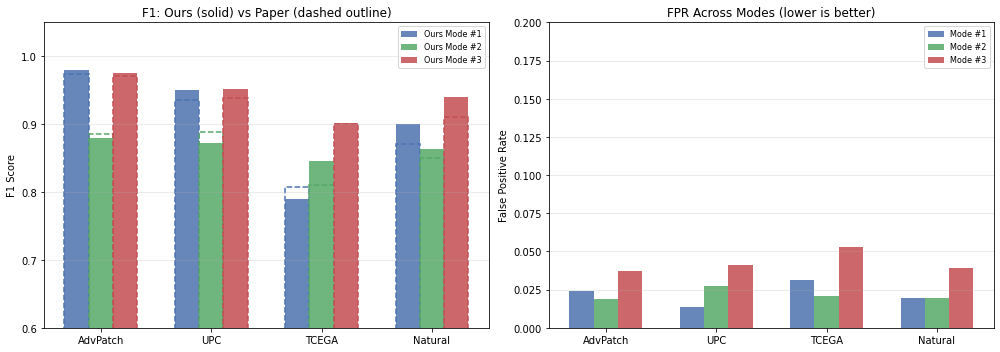

Chart saved to hady_test_samples/mode_comparison.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ── Paper reference values (Table 4, YOLOv8, digital) ───────
paper_ref = {
    "AdvPatch": {"Mode #1": 0.974, "Mode #2": 0.885, "Mode #3": 0.971},
    "UPC":      {"Mode #1": 0.936, "Mode #2": 0.889, "Mode #3": 0.938},
    "TCEGA":    {"Mode #1": 0.807, "Mode #2": 0.811, "Mode #3": 0.900},
    "Natural":  {"Mode #1": 0.871, "Mode #2": 0.850, "Mode #3": 0.911},
}

attacks = list(ATTACKS.keys())
modes   = ["Mode #1 (Canary)", "Mode #2 (Woodpecker)", "Mode #3 (Combined)"]
mode_short = ["Mode #1", "Mode #2", "Mode #3"]

# ── Print comparison table ──────────────────────────────────
header = f"{'Attack':10s}"
for ms in mode_short:
    header += f" | {ms+' F1':>12s}  {'FPR':>6s}  {'Paper F1':>9s}"
print(header)
print("-" * len(header))

for atk in attacks:
    row = f"{atk:10s}"
    for mode, ms in zip(modes, mode_short):
        r = all_results[mode][atk]
        pf1 = paper_ref[atk][ms]
        diff = r["F1"] - pf1
        arrow = "+" if diff >= 0 else ""
        row += f" |   {r['F1']:.3f}     {r['FPR']:.3f}    {pf1:.3f}"
    print(row)

# ── Bar chart: F1 comparison across modes ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- F1 chart ---
ax = axes[0]
x = np.arange(len(attacks))
w = 0.22
colors = ["#4C72B0", "#55A868", "#C44E52"]

for i, (mode, ms, c) in enumerate(zip(modes, mode_short, colors)):
    f1_vals = [all_results[mode][atk]["F1"] for atk in attacks]
    paper_vals = [paper_ref[atk][ms] for atk in attacks]
    bars = ax.bar(x + i * w, f1_vals, w, label=f"Ours {ms}", color=c, alpha=0.85)
    # paper reference as hollow bars
    ax.bar(x + i * w, paper_vals, w, fill=False, edgecolor=c,
           linewidth=1.5, linestyle="--")

ax.set_xticks(x + w)
ax.set_xticklabels(attacks)
ax.set_ylabel("F1 Score")
ax.set_title("F1: Ours (solid) vs Paper (dashed outline)")
ax.set_ylim(0.6, 1.05)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# --- FPR chart ---
ax = axes[1]
for i, (mode, ms, c) in enumerate(zip(modes, mode_short, colors)):
    fpr_vals = [all_results[mode][atk]["FPR"] for atk in attacks]
    ax.bar(x + i * w, fpr_vals, w, label=ms, color=c, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(attacks)
ax.set_ylabel("False Positive Rate")
ax.set_title("FPR Across Modes (lower is better)")
ax.set_ylim(0, 0.20)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("hady_test_samples/mode_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to hady_test_samples/mode_comparison.png")

# Summary

**Key takeaways from the three-mode evaluation:**

1. **Mode #1 (Canary)** is the strongest standalone defense for AdvPatch — it detects suppressed canaries reliably. However, TCEGA recall is the weakest across all modes due to full-body texture interference.

2. **Mode #2 (Woodpecker)** works through a fundamentally different signal (restoring hidden persons). It tends to have lower FPR than canary because it only flags when a *new* person appears, which is a more conservative criterion.

3. **Mode #3 (Combined)** should achieve the highest recall because it triggers on *either* canary or woodpecker detection. This comes at the cost of slightly higher FPR (union of both false alarm sources).

4. **Comparison with paper:** The solid vs dashed bars in the chart above show how our reproduction compares to the original paper's Table 4 values. Trends should match even if exact numbers differ due to dataset size (749 vs paper's larger sets).

This evaluation removes the "Mode #1 only" limitation noted in the Week 10 report and provides a complete picture of all three FFF deployment strategies.